## [Data Science] Team 40 - Zomato Delivery ETA Prediction


### **1. Import Data from Kaggle**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabhbadole/zomato-delivery-operations-analytics-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\emili\.cache\kagglehub\datasets\saurabhbadole\zomato-delivery-operations-analytics-dataset\versions\1


#### 1.1 Read Data 

In [3]:
import pandas as pd
df = pd.read_csv("Zomato Dataset.csv")
df.isnull().sum().sort_values(ascending=False)

Delivery_person_Ratings        1908
Delivery_person_Age            1854
Time_Orderd                    1731
City                           1200
multiple_deliveries             993
Weather_conditions              616
Road_traffic_density            601
Festival                        228
ID                                0
Delivery_person_ID                0
Restaurant_latitude               0
Restaurant_longitude              0
Time_Order_picked                 0
Order_Date                        0
Delivery_location_latitude        0
Delivery_location_longitude       0
Type_of_vehicle                   0
Type_of_order                     0
Vehicle_condition                 0
Time_taken (min)                  0
dtype: int64

### **2. Data Cleaning**

In [4]:
df = df.dropna(subset=['Time_Orderd'])

In [5]:
df.drop(columns=[
    'Delivery_person_ID',
    'Delivery_person_Ratings',
    'Delivery_person_Age'
], inplace=True)

In [6]:
df.head()

,ID,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [7]:
df.isnull().sum().sort_values(ascending=False)

City                           1144
multiple_deliveries             943
Festival                        219
ID                                0
Restaurant_latitude               0
Order_Date                        0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Weather_conditions                0
Time_Order_picked                 0
Time_Orderd                       0
Road_traffic_density              0
Type_of_vehicle                   0
Type_of_order                     0
Vehicle_condition                 0
Time_taken (min)                  0
dtype: int64

In [8]:
df['Festival'].fillna('No', inplace = True)

C:\Users\emili\AppData\Local\Temp\ipykernel_21420\2019699184.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Festival'].fillna('No', inplace = True)


In [9]:
df.isnull().sum().sort_values(ascending=False)

City                           1144
multiple_deliveries             943
ID                                0
Restaurant_latitude               0
Restaurant_longitude              0
Order_Date                        0
Time_Orderd                       0
Delivery_location_latitude        0
Delivery_location_longitude       0
Weather_conditions                0
Time_Order_picked                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_vehicle                   0
Type_of_order                     0
Festival                          0
Time_taken (min)                  0
dtype: int64

In [10]:
num_cols = ['City','multiple_deliveries']
for col in num_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\emili\AppData\Local\Temp\ipykernel_21420\2584604526.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [11]:
df.isnull().sum().sort_values(ascending=False)

ID                             0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
dtype: int64

In [12]:
df.shape

(43853, 17)

In [13]:
df

,ID,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45579,0x7c09,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35,11:45,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32
45580,0xd641,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55,20:10,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36
45581,0x4f8d,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50,24:05:00,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16
45582,0x5eee,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35,13:40,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26


In [14]:
import numpy as np

# --- Date parse ---
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y", errors="coerce")
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M", errors="coerce")

# --- Date features ---
df["day_of_week"] = df["Order_Date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

# --- Time features ---
df["hour_of_day"] = df["Time_Orderd"].dt.hour
df["minute_of_hour"] = df["Time_Orderd"].dt.minute

# cyclical encoding (optional, good for ML)
df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

# clean display version of time (HH:MM)
df["Time_Orderd_str"] = df["Time_Orderd"].dt.strftime("%H:%M")

# --- Distance (Haversine formula) ---
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df["distance_km"] = haversine(
    df["Restaurant_latitude"], df["Restaurant_longitude"],
    df["Delivery_location_latitude"], df["Delivery_location_longitude"]
)



In [15]:
df


,ID,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,...,City,Time_taken (min),day_of_week,is_weekend,hour_of_day,minute_of_hour,hour_sin,hour_cos,Time_Orderd_str,distance_km
0,0xcdcd,30.327968,78.046106,30.397968,78.116106,2022-02-12,1900-01-01 21:55:00,22:10,Fog,Jam,...,Metropolitian,46,5,1,21.0,55.0,-0.707107,0.707107,21:55,10.280582
1,0xd987,10.003064,76.307589,10.043064,76.347589,2022-02-13,1900-01-01 14:55:00,15:05,Stormy,High,...,Metropolitian,23,6,1,14.0,55.0,-0.500000,-0.866025,14:55,6.242319
2,0x2784,18.562450,73.916619,18.652450,74.006619,2022-03-04,1900-01-01 17:30:00,17:40,Sandstorms,Medium,...,Metropolitian,21,4,0,17.0,30.0,-0.965926,-0.258819,17:30,13.787860
3,0xc8b6,30.899584,75.809346,30.919584,75.829346,2022-02-13,1900-01-01 09:20:00,09:30,Sandstorms,Low,...,Metropolitian,20,6,1,9.0,20.0,0.707107,-0.707107,09:20,2.930258
4,0xdb64,26.463504,80.372929,26.593504,80.502929,2022-02-14,1900-01-01 19:50:00,20:05,Fog,Jam,...,Metropolitian,41,0,0,19.0,50.0,-0.965926,0.258819,19:50,19.396618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45579,0x7c09,26.902328,75.794257,26.912328,75.804257,2022-03-24,1900-01-01 11:35:00,11:45,Windy,High,...,Metropolitian,32,3,0,11.0,35.0,0.258819,-0.965926,11:35,1.489846
45580,0xd641,0.000000,0.000000,0.070000,0.070000,2022-02-16,1900-01-01 19:55:00,20:10,Windy,Jam,...,Metropolitian,36,2,0,19.0,55.0,-0.965926,0.258819,19:55,11.007735
45581,0x4f8d,13.022394,80.242439,13.052394,80.272439,2022-03-11,1900-01-01 23:50:00,24:05:00,Cloudy,Low,...,Metropolitian,16,4,0,23.0,50.0,-0.258819,0.965926,23:50,4.657195
45582,0x5eee,11.001753,76.986241,11.041753,77.026241,2022-03-07,1900-01-01 13:35:00,13:40,Cloudy,High,...,Metropolitian,26,0,0,13.0,35.0,-0.258819,-0.965926,13:35,6.232393


In [16]:
# -- Outliers Filtering ---
df = df[df["distance_km"] < 80].copy()


In [17]:
df.columns = df.columns.str.lower()

In [18]:
from datetime import datetime
df['week_num'] = df['order_date'].dt.isocalendar().week


In [19]:
df['user_id_fake'] = (
    df.groupby(['delivery_location_latitude', 'delivery_location_longitude'])
      .ngroup() + 1
)

In [20]:
df.rename(columns={'time_taken (min)': 'time_taken'},inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43697 entries, 0 to 45583
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           43697 non-null  object        
 1   restaurant_latitude          43697 non-null  float64       
 2   restaurant_longitude         43697 non-null  float64       
 3   delivery_location_latitude   43697 non-null  float64       
 4   delivery_location_longitude  43697 non-null  float64       
 5   order_date                   43697 non-null  datetime64[ns]
 6   time_orderd                  39644 non-null  datetime64[ns]
 7   time_order_picked            43697 non-null  object        
 8   weather_conditions           43697 non-null  object        
 9   road_traffic_density         43697 non-null  object        
 10  vehicle_condition            43697 non-null  int64         
 11  type_of_order                43697 non-null  o

### **3. Data Visualization - Part 1**

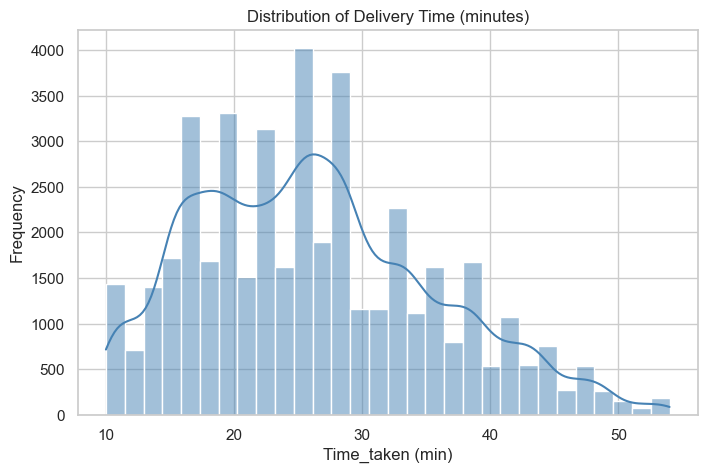

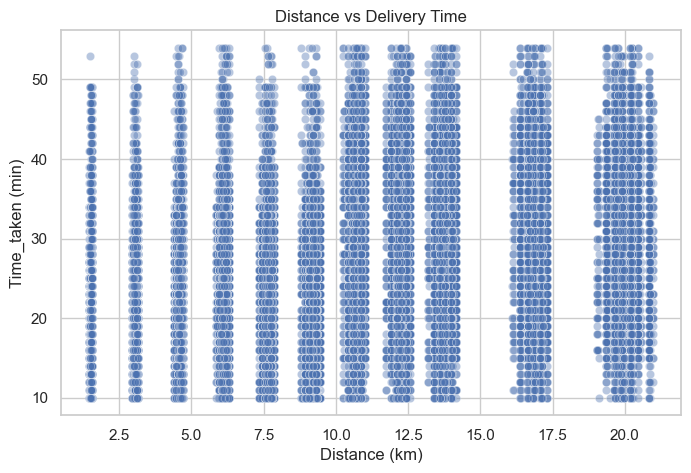

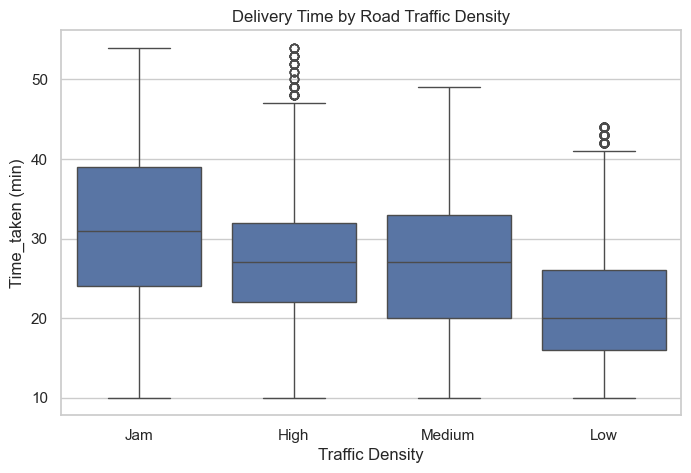

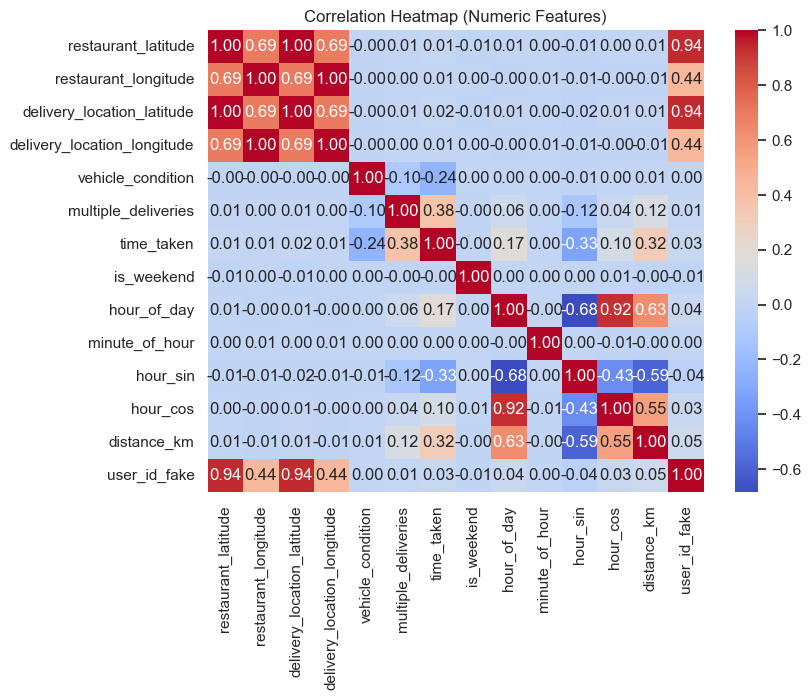

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set(style="whitegrid")

# 1. Histogram of delivery time
plt.figure(figsize=(8,5))
sns.histplot(df["time_taken"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Delivery Time (minutes)")
plt.xlabel("Time_taken (min)")
plt.ylabel("Frequency")
plt.show()

# 2. Scatterplot: distance vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x="distance_km", y="time_taken", data=df, alpha=0.4)
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Time_taken (min)")
plt.show()

# 3. Boxplot: traffic impact
plt.figure(figsize=(8,5))
sns.boxplot(x="road_traffic_density", y="time_taken", data=df)
plt.title("Delivery Time by Road Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Time_taken (min)")
plt.show()

# 4. Correlation heatmap
plt.figure(figsize=(8,6))
numeric_cols = df.select_dtypes(include=["float64","int64"]).columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


### **4. Feature Engineering**

#### **4.1. Delayed Orders Variable Creation**

In [24]:
from sklearn.linear_model import LinearRegression

# Prepare features
feature_cols = ['distance_km', 'vehicle_condition', 'multiple_deliveries', 
                'hour_of_day', 'is_weekend']
categorical_cols = ['road_traffic_density', 'weather_conditions', 'city', 'type_of_vehicle','festival']

X = df[feature_cols].copy()
for col in categorical_cols:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
    X = pd.concat([X, dummies], axis=1)

# Fill any NaNs
X = X.fillna(X.median())

# Fit model
model = LinearRegression()
model.fit(X, df['time_taken'])

# Calculate delay
df['expected_time'] = model.predict(X)
df['time_residual'] = df['time_taken'] - df['expected_time']
residual_std = df['time_residual'].std()



df['is_delayed'] = (df['time_residual'] > 1.5 * residual_std).astype(int)

print(f"Delay rate: {df['is_delayed'].mean():.2%}")
print(f"Threshold: {1.5 * residual_std:.1f} minutes above expected")

Delay rate: 7.07%
Threshold: 10.2 minutes above expected


In [25]:
user_delay_rate = (
    df.groupby('user_id_fake')['is_delayed']
      .mean()
      .reset_index(name='delay_rate')
)

user_delay_rate

,user_id_fake,delay_rate
0,1,0.050314
1,2,0.050314
2,3,0.049669
3,4,0.049689
4,5,0.037855
...,...,...
4359,4360,0.000000
4360,4361,0.000000
4361,4362,0.250000
4362,4363,0.000000


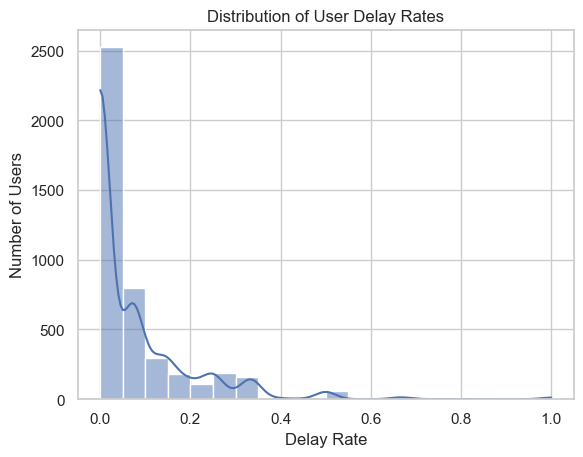

In [26]:

sns.histplot(user_delay_rate['delay_rate'], bins=20, kde=True)
plt.title('Distribution of User Delay Rates')
plt.xlabel('Delay Rate')
plt.ylabel('Number of Users')
plt.show()


### **5. Impact and Correlation Analysis - Delay Rate vs Order Frequency**

--- User Base Summary ---
Total Unique Users: 4364
Core Users Analyzed: 3854


--- Correlation: Past Delays vs. Future Orders ---
Correlation (1-Week Lag): r = -0.004
Correlation (2-Week Lag): r = 0.001




C:\Users\emili\AppData\Local\Temp\ipykernel_21420\655334704.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='delay_group', y='order_count', ax=axes[0, 0], palette='viridis')
C:\Users\emili\AppData\Local\Temp\ipykernel_21420\655334704.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lag_data, x='Lag', y='Correlation', ax=axes[1, 1], palette='coolwarm')


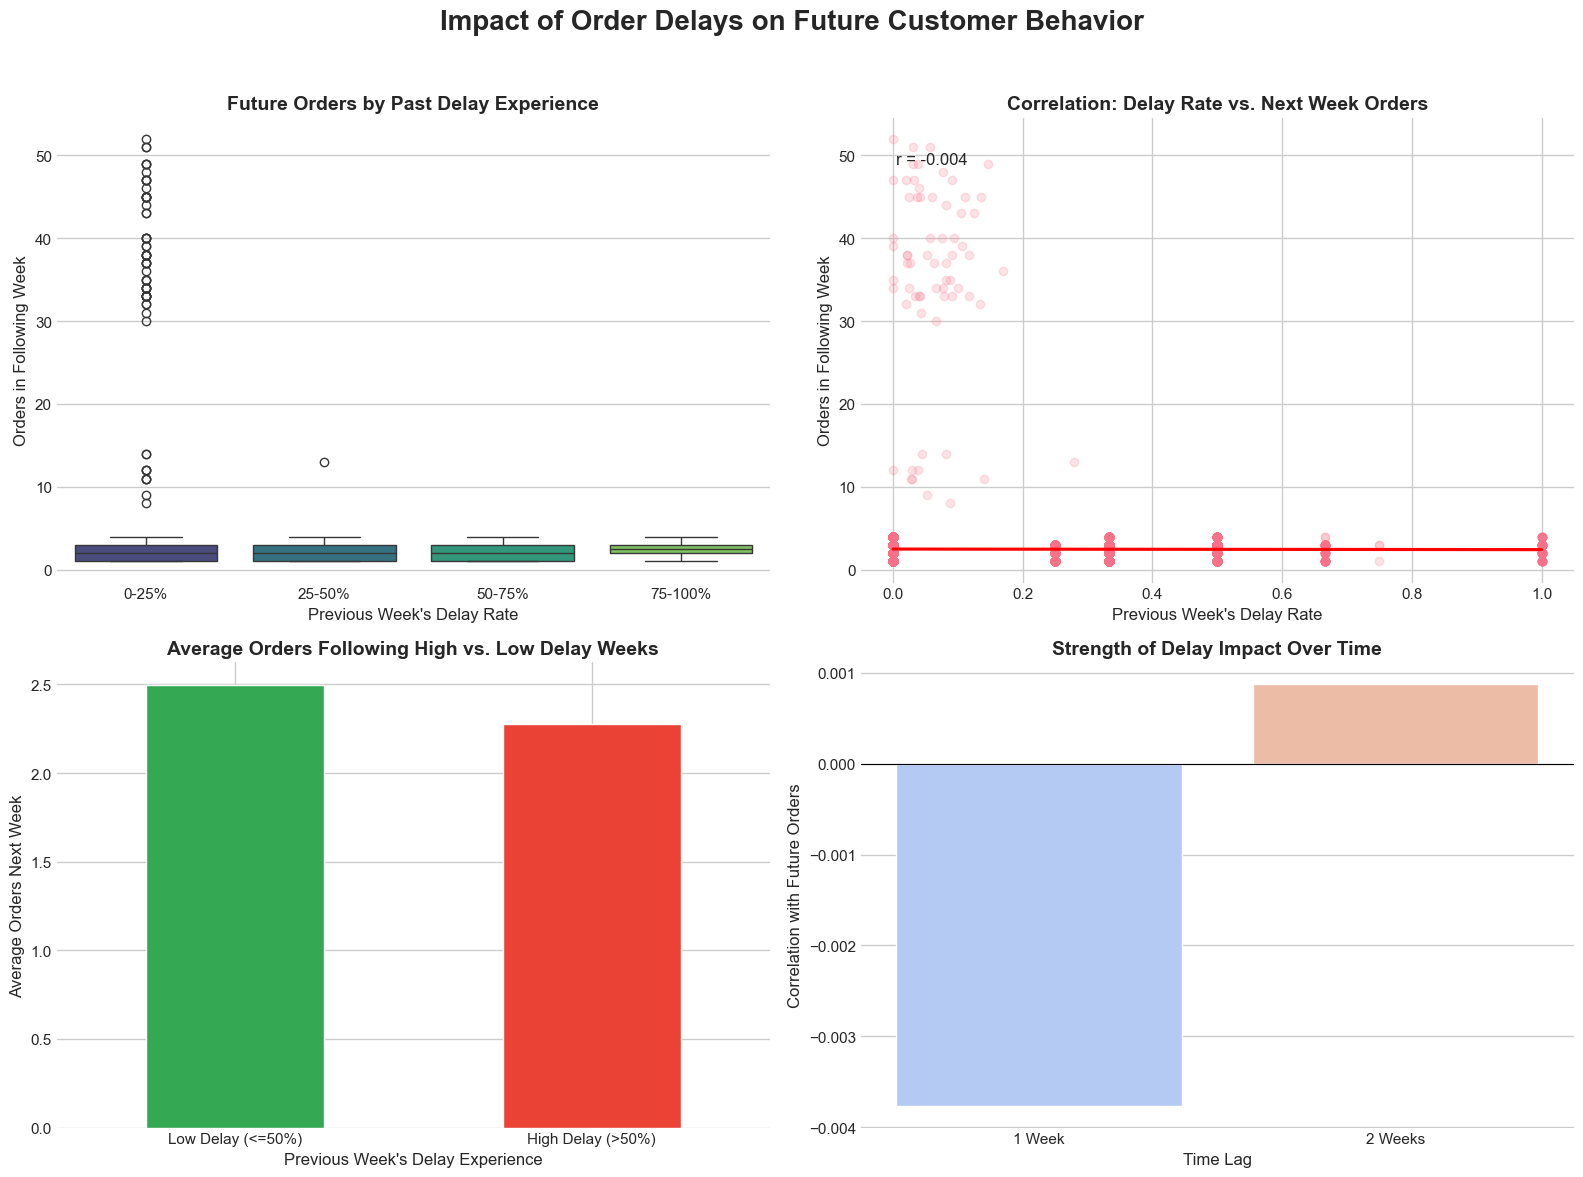

In [ ]:
import seaborn as sns
from scipy.stats import pearsonr

# --- 1. User Segmentation ---

# Aggregate key metrics at the user level
user_summary = df.groupby('user_id_fake').agg(
    total_orders=('id', 'count'),
    delay_rate=('is_delayed', 'mean')
).reset_index()

# Filter for a core group of engaged users, removing low-activity users and outliers
Q1 = user_summary['total_orders'].quantile(0.25)
Q3 = user_summary['total_orders'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

core_users_df = user_summary[
    (user_summary['total_orders'] >= 3) &
    (user_summary['total_orders'] <= upper_bound)
]

print("--- User Base Summary ---")
print(f"Total Unique Users: {user_summary['user_id_fake'].nunique()}")
print(f"Core Users Analyzed: {len(core_users_df)}")
print("\n")


# --- 2. Lagged Impact Analysis ---

df_sorted = df.sort_values(['user_id_fake', 'order_date'])

# Aggregate data into weekly snapshots for each user
weekly_agg = df_sorted.groupby([
    'user_id_fake',
    pd.Grouper(key='order_date', freq='W-MON')
]).agg(
    order_count=('id', 'count'),
    delay_rate=('is_delayed', 'mean')
).reset_index()

weekly_agg = weekly_agg.sort_values(['user_id_fake', 'order_date'])

# Create lagged delay metrics to see if past delays affect current orders
weekly_agg['prev_week_delay_rate'] = weekly_agg.groupby('user_id_fake')['delay_rate'].shift(1)
weekly_agg['prev_2week_delay_rate'] = weekly_agg.groupby('user_id_fake')['delay_rate'].shift(2)

# Final dataset for analysis, removing entries without prior week data
analysis_df = weekly_agg.dropna().copy()


# --- 3. Correlation & Insights ---

corr_lag1, p_lag1 = pearsonr(analysis_df['prev_week_delay_rate'], analysis_df['order_count'])
corr_lag2, p_lag2 = pearsonr(analysis_df['prev_2week_delay_rate'], analysis_df['order_count'])

print("--- Correlation: Past Delays vs. Future Orders ---")
print(f"Correlation (1-Week Lag): r = {corr_lag1:.3f}")
print(f"Correlation (2-Week Lag): r = {corr_lag2:.3f}")
print("\n")

# Bin delay rates into clear groups for visualization
analysis_df['delay_group'] = pd.cut(
    analysis_df['prev_week_delay_rate'],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=['0-25%', '25-50%', '50-75%', '75-100%'],
    include_lowest=True
)


# --- 4. Executive Summary Visualization ---

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Impact of Order Delays on Future Customer Behavior', fontsize=20, weight='bold')

# Plot 1: Order Count by Previous Week's Delay Rate
sns.boxplot(data=analysis_df, x='delay_group', y='order_count', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Future Orders by Past Delay Experience', fontsize=14, weight='bold')
axes[0, 0].set_xlabel("Previous Week's Delay Rate", fontsize=12)
axes[0, 0].set_ylabel("Orders in Following Week", fontsize=12)

# Plot 2: Scatterplot showing the correlation
sns.regplot(data=analysis_df, x='prev_week_delay_rate', y='order_count',
            ax=axes[0, 1], scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'})
axes[0, 1].set_title('Correlation: Delay Rate vs. Next Week Orders', fontsize=14, weight='bold')
axes[0, 1].set_xlabel("Previous Week's Delay Rate", fontsize=12)
axes[0, 1].set_ylabel("Orders in Following Week", fontsize=12)
axes[0, 1].text(0.05, 0.9, f'r = {corr_lag1:.3f}', transform=axes[0, 1].transAxes, fontsize=12)

# Plot 3: Comparison of high vs. low delay impact
analysis_df['delay_level'] = np.where(analysis_df['prev_week_delay_rate'] > 0.5, 'High Delay (>50%)', 'Low Delay (<=50%)')
order_impact = analysis_df.groupby('delay_level')['order_count'].mean().reindex(['Low Delay (<=50%)', 'High Delay (>50%)'])

order_impact.plot(kind='bar', ax=axes[1, 0], color=['#34A853', '#EA4335'], rot=0)
axes[1, 0].set_title('Average Orders Following High vs. Low Delay Weeks', fontsize=14, weight='bold')
axes[1, 0].set_xlabel("Previous Week's Delay Experience", fontsize=12)
axes[1, 0].set_ylabel("Average Orders Next Week", fontsize=12)

# Plot 4: Correlation strength over time
lag_data = pd.DataFrame({
    'Lag': ['1 Week', '2 Weeks'],
    'Correlation': [corr_lag1, corr_lag2]
})
sns.barplot(data=lag_data, x='Lag', y='Correlation', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].axhline(0, color='black', lw=0.8)
axes[1, 1].set_title('Strength of Delay Impact Over Time', fontsize=14, weight='bold')
axes[1, 1].set_xlabel("Time Lag", fontsize=12)
axes[1, 1].set_ylabel("Correlation with Future Orders", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [34]:
import statsmodels.api as sm

df_sorted = df.sort_values(['user_id_fake', 'order_date']).copy()

df_lag = df_sorted.copy()
df_lag['year_week'] = df_lag['order_date'].dt.isocalendar().week.astype(str) + '_' + df_lag['order_date'].dt.year.astype(str)

weekly_user_data = df_lag.groupby(['user_id_fake', 'year_week']).agg({
    'is_delayed': ['sum', 'mean', 'count'],
    'order_date': 'min'
}).reset_index()

weekly_user_data.columns = ['user_id', 'year_week', 'delayed_orders', 'delay_rate', 'order_count', 'week_start']
weekly_user_data = weekly_user_data.sort_values(['user_id', 'week_start'])

print(f"Weekly observations: {len(weekly_user_data)}")
print(f"Unique users: {weekly_user_data['user_id'].nunique()}")
print(f"\nDelay Rate:\n{weekly_user_data['delay_rate'].describe()}")
print(f"\nOrder Count:\n{weekly_user_data['order_count'].describe()}")
weekly_user_data['delay_rate_lag1'] = weekly_user_data.groupby('user_id')['delay_rate'].shift(1)
weekly_user_data['delay_rate_lag2'] = weekly_user_data.groupby('user_id')['delay_rate'].shift(2)

regression_df = weekly_user_data.dropna(subset=['delay_rate_lag1', 'delay_rate_lag2']).copy()
print(f"N = {len(regression_df)}")

models = {}
results_summary = []

for lag, col in [(1, 'delay_rate_lag1'), (2, 'delay_rate_lag2')]:
    X = sm.add_constant(regression_df[[col]])
    y = regression_df['order_count']
    
    model = sm.OLS(y, X).fit()
    models[f'lag{lag}'] = model
    
    print(f"\n{'='*60}")
    print(f"Model {lag}: {lag}-Week Lag")
    print(f"{'='*60}")
    print(model.summary())
    
    coef = model.params[col]
    pval = model.pvalues[col]
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    
    results_summary.append({
        'Model': f'{lag}W',
        'Coefficient': f'{coef:.4f}{sig}',
        'P-value': f'{pval:.4e}',
        'R²': f'{model.rsquared:.4f}'
    })

X_combined = sm.add_constant(regression_df[['delay_rate_lag1', 'delay_rate_lag2']])
y = regression_df['order_count']
model_combined = sm.OLS(y, X_combined).fit()
models['combined'] = model_combined

print(f"\n{'='*60}")
print("Model 3: Combined (1W + 2W)")
print(f"{'='*60}")
print(model_combined.summary())

results_summary.append({
    'Model': 'Both',
    'Coefficient': f"{model_combined.params['delay_rate_lag1']:.4f} / {model_combined.params['delay_rate_lag2']:.4f}",
    'P-value': f"{model_combined.pvalues['delay_rate_lag1']:.4e} / {model_combined.pvalues['delay_rate_lag2']:.4e}",
    'R²': f'{model_combined.rsquared:.4f}'
})

print(f"\n{'='*60}")
print("Summary")
print(f"{'='*60}")
print(pd.DataFrame(results_summary).to_string(index=False))

print(f"\n{'='*60}")
coef1 = model_combined.params['delay_rate_lag1']
coef2 = model_combined.params['delay_rate_lag2']
sig1 = model_combined.pvalues['delay_rate_lag1'] < 0.05
sig2 = model_combined.pvalues['delay_rate_lag2'] < 0.05

print(f"1W Lag: {coef1:.4f}")
print(f"2W Lag: {coef2:.4f}")
print(f"{'='*60}")

Weekly observations: 17876
Unique users: 4364

Delay Rate:
count    17876.000000
mean         0.071076
std          0.190598
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: delay_rate, dtype: float64

Order Count:
count    17876.000000
mean         2.444451
std          2.973617
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         82.000000
Name: order_count, dtype: float64
N = 9509

Model 1: 1-Week Lag
                            OLS Regression Results                            
Dep. Variable:            order_count   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.07980
Date:                Mon, 13 Oct 2025   Prob (F-statistic):              0.778
Time:                        21:48:11   Log-Likelihood:                -23957.
No. 

### **6. Prediction Modelling - Linear Regression + Random Forest**

In [38]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

#selection of target variables
target = 'time_taken'
features = [ 'distance_km' , 'hour_of_day' , 'day_of_week' , 'is_weekend' , 'road_traffic_density' , 'multiple_deliveries' , 'festival' , 'city' , 'weather_conditions' ]

X = df[features]
y = df[target]

#Handle Categorical Variables
X = pd.get_dummies(X, drop_first=True)

data_for_drop = pd.concat([X, y], axis=1)
data_cleaned = data_for_drop.dropna()


X = data_cleaned.drop(target, axis=1)
y = data_cleaned[target]


#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

#Predictions & Metrics
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

#Coefficients for Feature Impact
coefficients = pd.DataFrame({ 'Feature' : X . columns , 'Coefficient' : model . coef_ } ) . sort_values ( by = "Coefficient" , ascending = True )
print(coefficients)

MAE: 5.708167148673439
RMSE: 7.140061602188272
                          Feature  Coefficient
6        road_traffic_density_Low    -6.071846
14       weather_conditions_Sunny    -6.038269
10                     city_Urban    -2.626573
7     road_traffic_density_Medium    -2.537606
13      weather_conditions_Stormy    -2.447466
12  weather_conditions_Sandstorms    -2.382891
15       weather_conditions_Windy    -2.321884
11         weather_conditions_Fog    -0.124830
1                     hour_of_day    -0.096838
3                      is_weekend    -0.089484
2                     day_of_week     0.030604
0                     distance_km     0.390940
5        road_traffic_density_Jam     0.844845
4             multiple_deliveries     4.067977
8                    festival_Yes    11.820195
9                 city_Semi-Urban    12.769916


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


# 1. Model creation
rf_model = RandomForestRegressor(
    n_estimators=200, 
    random_state=42,
    max_depth=None, 
    n_jobs=-1    
)
rf_model.fit(X_train, y_train)


# 2. Predict & Evaluate

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)


# 3. Feature Importance

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances.head(10))


Random Forest MAE: 5.293991714821312
Random Forest RMSE: 6.7998087301532095
                      Feature  Importance
0                 distance_km    0.361055
6    road_traffic_density_Low    0.147045
4         multiple_deliveries    0.130927
2                 day_of_week    0.069036
14   weather_conditions_Sunny    0.068190
1                 hour_of_day    0.042640
11     weather_conditions_Fog    0.036400
8                festival_Yes    0.031015
15   weather_conditions_Windy    0.028373
13  weather_conditions_Stormy    0.017250


In [ ]:
import statsmodels.api as sm

# 1. Add a constant to the feature matrix
X_const = sm.add_constant(X)

# 2. Convert the dataframes to NumPy float arrays to avoid the ValueError
X_array = X_const.values.astype(float)
y_array = y.values.astype(float)

# 3. Fit the OLS model
model_ols = sm.OLS(y_array, X_array).fit()

# 4. Print the summary
print(model_ols.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     1857.
Date:                Sun, 12 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:42:22   Log-Likelihood:            -1.3393e+05
No. Observations:               39644   AIC:                         2.679e+05
Df Residuals:                   39627   BIC:                         2.680e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         25.9797      0.199    130.519      0.0

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

target = 'time_taken'
features = [
    'distance_km', 'hour_of_day', 'day_of_week', 'is_weekend',
    'road_traffic_density', 'multiple_deliveries', 'festival',
    'city', 'weather_conditions'
]

X = df[features].copy()
y = df[target].copy()

X = pd.get_dummies(X, drop_first=True)

data_combined = pd.concat([X, y], axis=1)
data_cleaned = data_combined.dropna()

X = data_cleaned.drop(target, axis=1)
y = data_cleaned[target]

print(f"Final sample size: {len(X)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nHoldout Test Performance:")
print(f"  MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"  R2: {r2_score(y_test, y_pred):.4f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

mae_cv = -np.mean(cross_val_score(
    model, X, y, cv=kf,
    scoring=make_scorer(mean_absolute_error, greater_is_better=False)
))

rmse_cv = -np.mean(cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer))
r2_cv = np.mean(cross_val_score(model, X, y, cv=kf, scoring='r2'))

print("\nCross-Validation Performance (K=5):")
print(f"  MAE: {mae_cv:.4f}")
print(f"  RMSE: {rmse_cv:.4f}")
print(f"  R2: {r2_cv:.4f}")

X_const = sm.add_constant(X)
X_array = X_const.values.astype(float)
y_array = y.values.astype(float)

ols_model = sm.OLS(y_array, X_array).fit()

print("\n" + "="*70)
print("OLS REGRESSION SUMMARY")
print("="*70)
print(ols_model.summary(xname=X_const.columns.tolist()))

Final sample size: 39644

Holdout Test Performance:
  MAE: 5.7082
  RMSE: 7.1401
  R2: 0.4242

Cross-Validation Performance (K=5):
  MAE: 5.6820
  RMSE: 7.0978
  R2: 0.4279

OLS REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     1857.
Date:                Mon, 13 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:05:43   Log-Likelihood:            -1.3393e+05
No. Observations:               39644   AIC:                         2.679e+05
Df Residuals:                   39627   BIC:                         2.680e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
             

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

X_rf = X
y_rf = y

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

y_pred_rf = rf_model.predict(X_test_rf)

print("Holdout Test Performance (Random Forest):")
print(f"  MAE: {mean_absolute_error(y_test_rf, y_pred_rf):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_rf, y_pred_rf)):.4f}")
print(f"  R2: {r2_score(y_test_rf, y_pred_rf):.4f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_cv_rf = -np.mean(cross_val_score(
    rf_model, X_rf, y_rf, cv=kf,
    scoring=make_scorer(mean_absolute_error, greater_is_better=False)
))

rmse_cv_rf = -np.mean(cross_val_score(
    rf_model, X_rf, y_rf, cv=kf,
    scoring=make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)), greater_is_better=False)
))

r2_cv_rf = np.mean(cross_val_score(rf_model, X_rf, y_rf, cv=kf, scoring='r2'))

print("\nCross-Validation Performance (Random Forest, K=5):")
print(f"  MAE: {mae_cv_rf:.4f}")
print(f"  RMSE: {rmse_cv_rf:.4f}")
print(f"  R2: {r2_cv_rf:.4f}")

importances = pd.DataFrame({
    'Feature': X_rf.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(importances.head(10).to_string(index=False))

Holdout Test Performance (Random Forest):
  MAE: 5.0571
  RMSE: 6.4712
  R2: 0.5270

Cross-Validation Performance (Random Forest, K=5):
  MAE: 4.9987
  RMSE: 6.3941
  R2: 0.5357

Top 10 Important Features:
                 Feature  Importance
             distance_km    0.283008
     multiple_deliveries    0.149167
road_traffic_density_Low    0.098772
weather_conditions_Sunny    0.079501
             hour_of_day    0.074692
road_traffic_density_Jam    0.056694
            festival_Yes    0.051816
             day_of_week    0.041934
  weather_conditions_Fog    0.030592
weather_conditions_Windy    0.027591


### **7. Comparing Random Forest vs Benchmark Model (LR)**

In [39]:
# get predictions (this produced 39644 values in your run)
preds = rf_model.predict(X_rf)

# create column filled with NaN, then fill for the cleaned rows
df['predicted_time_rf'] = np.nan
df.loc[data_cleaned.index, 'predicted_time_rf'] = preds


In [40]:
df['diff_rf_tt'] = df['time_taken'] - df['predicted_time_rf']
df['is_delayed_rf'] = (df['diff_rf_tt'] > 10.2).astype(int)



In [41]:
df_cleaned = df[df['predicted_time_rf'].isna()!= True]

In [42]:
print(f"Delay rate RF: {df_cleaned['is_delayed_rf'].mean():.2%}")

rf_delay_rate = df_cleaned['is_delayed_rf'].mean()
bm_delay_rate = df['is_delayed'].mean()

Delay rate RF: 2.82%


In [44]:
AOV = 4.08
T_USERS = df.count()[0]
unit_expected_uplift = AOV * ((bm_delay_rate - rf_delay_rate) * 0.0512)
total_expected_uplift = unit_expected_uplift * T_USERS
print(f"Expected $ uplift per order: {unit_expected_uplift:.4f}")
print(f"Total Expected $ uplift in userbase: {total_expected_uplift:.4f}")

Expected $ uplift per order: 0.0089
Total Expected $ uplift in userbase: 388.1091


C:\Users\emili\AppData\Local\Temp\ipykernel_21420\1428336878.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  T_USERS = df.count()[0]


## Confidence Intervals

In [45]:
import numpy as np

boot_diffs = []
n_boot = 500

for _ in range(n_boot):
    sample = df_cleaned.sample(frac=1, replace=True)
    p_prev_b = sample['is_delayed'].mean()
    p_rf_b   = sample['is_delayed_rf'].mean()
    uplift_b = AOV * ((p_prev_b - p_rf_b) * 0.05)
    boot_diffs.append(uplift_b)

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f"95% CI for uplift per order: [{ci_low:.4f}, {ci_high:.4f}]")


95% CI for uplift per order: [0.0083, 0.0092]
